## Social Media Sentiment Analysis

### Problem Statement: 

#### Classify social media comments into sentiment classes (positive, negative, neutral) and understand basic patterns in the data using Python, pandas, and scikit‑learn.

## 1. Data Loading and Preparation

#### We load a synthetic social media dataset, keep only the text and original emotion label columns, and create a working copy with a simple text length feature for basic analysis.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set(style="whitegrid")

# Load CSV
df = pd.read_csv("sentimentdataset.csv")

text_col = "Text"       # your text column
label_col = "Sentiment" # your original label column

# Keep only needed columns and work on a copy
data = df[[text_col, label_col]].dropna().copy()
data[text_col] = data[text_col].astype(str)
data[label_col] = data[label_col].str.strip()

# Simple feature for EDA
data["text_length"] = data[text_col].str.len()
data.head()

,Text,Sentiment,text_length
0,Enjoying a beautiful day at the park! ...,Positive,52
1,Traffic was terrible this morning. ...,Negative,52
2,Just finished an amazing workout! 💪 ...,Positive,51
3,Excited about the upcoming weekend getaway! ...,Positive,52
4,Trying out a new recipe for dinner tonight. ...,Neutral,52


## 2. Exploratory Data Analysis

#### We first explore the distribution of sentiment labels and the length of comments to understand the dataset and potential issues such as class imbalance.

In [2]:
# Raw label distribution
data[label_col].value_counts()

Sentiment
Positive          45
Joy               44
Excitement        37
Contentment       19
Neutral           18
                  ..
LostLove           1
EmotionalStorm     1
Suffering          1
Bittersweet        1
Intrigue           1
Name: count, Length: 191, dtype: int64

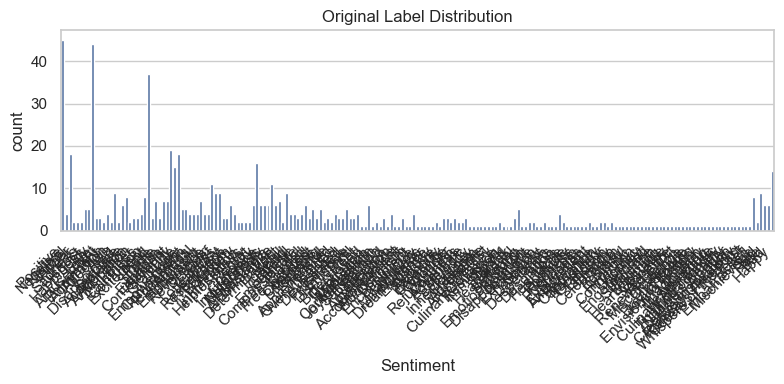

In [3]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x=label_col)
plt.title("Original Label Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

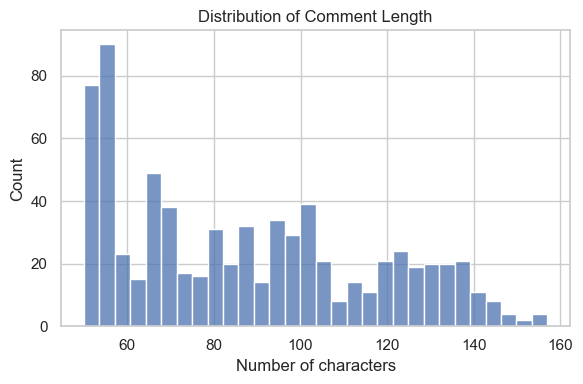

In [4]:
plt.figure(figsize=(6, 4))
sns.histplot(data["text_length"], bins=30)
plt.title("Distribution of Comment Length")
plt.xlabel("Number of characters")
plt.tight_layout()
plt.show()

## 3. Label Grouping (Emotions → Sentiment)

#### The original dataset contains fine-grained emotion labels such as Joy, Fear, Admiration, and Disgust. For this project, these emotions are grouped into three broader sentiment classes — positive, negative, and neutral — to create a simpler and more learnable classification task.

In [5]:
mapping = {
    "Positive": "positive",
    "Happiness": "positive",
    "Joy": "positive",
    "Love": "positive",
    "Amusement": "positive",
    "Enjoyment": "positive",
    "Admiration": "positive",
    "Affection": "positive",
    "Awe": "positive",
    "Acceptance": "positive",
    "Adoration": "positive",
    "Anticipation": "positive",

    "Negative": "negative",
    "Anger": "negative",
    "Fear": "negative",
    "Sadness": "negative",
    "Disgust": "negative",
    "Disappointed": "negative",

    "Neutral": "neutral",
    "Surprise": "neutral",
}

data["label_clean"] = data[label_col].map(mapping)
data = data.dropna(subset=["label_clean"]).copy()
data["label_clean"].value_counts()

label_clean
positive    130
neutral      24
negative     17
Name: count, dtype: int64

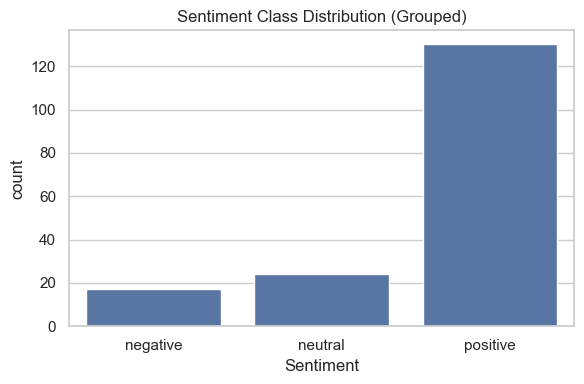

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="label_clean",
              order=["negative", "neutral", "positive"])
plt.title("Sentiment Class Distribution (Grouped)")
plt.xlabel("Sentiment")
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

#### We clean the raw text by lower‑casing, removing URLs, mentions, hashtags, and non‑alphabetic characters.The cleaned text will be used to build TF‑IDF features for the models.

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

data["clean_text"] = data[text_col].apply(clean_text)
data[["clean_text", "label_clean"]].head()

,clean_text,label_clean
0,enjoying a beautiful day at the park,positive
1,traffic was terrible this morning,negative
2,just finished an amazing workout,positive
3,excited about the upcoming weekend getaway,positive
4,trying out a new recipe for dinner tonight,neutral


## 5. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_text"],
    data["label_clean"],
    test_size=0.2,
    random_state=42,
    stratify=data["label_clean"]
)

## 6. Modeling

#### We compare two baseline linear models on TF‑IDF features:
#### Logistic Regression and Linear SVM.
#### Both are common, strong baselines for text classification.

### Logistic Regression

In [9]:
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
logreg_pred = logreg_pipeline.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.7714285714285715
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.00      0.00      0.00         5
    positive       0.77      1.00      0.87        27

    accuracy                           0.77        35
   macro avg       0.26      0.33      0.29        35
weighted avg       0.60      0.77      0.67        35



/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

### Linear SVM

In [10]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("clf", LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 0.7714285714285715
              precision    recall  f1-score   support

    negative       1.00      0.33      0.50         3
     neutral       0.00      0.00      0.00         5
    positive       0.79      0.96      0.87        27

    accuracy                           0.77        35
   macro avg       0.60      0.43      0.46        35
weighted avg       0.69      0.77      0.71        35



/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


## 7. Confusion Matrix for Best Model

#### Logistic Regression and Linear SVM achieved the same overall test accuracy (about 0.77). However, Linear SVM performed slightly better on minority classes, so it is used here as the final model for the confusion matrix and sample predictions.

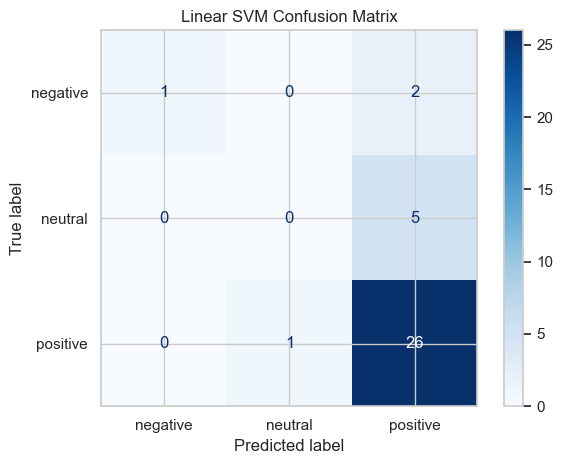

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=["negative", "neutral", "positive"],
    cmap="Blues"
)
plt.title("Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
examples = X_test.sample(5, random_state=42)

for idx, text in examples.items():
    print("TEXT:", text)
    print("TRUE:", y_test.loc[idx])
    print("PRED:", svm_pipeline.predict([text])[0])
    print("-" * 60)

TEXT: just finished an amazing workout
TRUE: positive
PRED: positive
------------------------------------------------------------
TEXT: new year  new fitness goals
TRUE: positive
PRED: positive
------------------------------------------------------------
TEXT: missing summer vibes and beach days
TRUE: neutral
PRED: positive
------------------------------------------------------------
TEXT: walking the great wall of china  each step a testament to ancient engineering marvels
TRUE: positive
PRED: positive
------------------------------------------------------------
TEXT: surrounded by the colors of joy  a canvas painted with laughter and endless smiles
TRUE: positive
PRED: positive
------------------------------------------------------------
